In [80]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [84]:
def calculate_effective_span(aerodynamic_data):
    """
    
    """

    # --- Considers only a single observation ---
    aerodynamic_data = aerodynamic_data.iloc[1::2].reset_index(drop=True)

    # --- Finds the maximum lift coefficient idex for linear regime filtering ---
    stall_idx = aerodynamic_data['CL'].idxmax()

    # --- Extracts the linear regime aerodynamic coefficients data ---
    CL = aerodynamic_data['CL'][:stall_idx-1]
    CD = aerodynamic_data['CD'][:stall_idx-1]

    # --- Fits the polynomial curve corresponding to CD = CD_min + K * (CL - CL_min_D)^2 ---
    K, _, _ = np.polyfit(CL, CD, 2)
    K = float(K)

    # --- Uses the K value to calculate the effective aspect ratio value ---
    AR_eff = 1 / (np.pi * 0.75 * K)

    # --- Calculates the actual reference area ---
    S_ref = 2 * (0.2165 * 0.766)

    # --- Calculates the effective span considering the actual reference area ---
    b_eff = np.sqrt(AR_eff * S_ref)
    
    return b_eff

In [85]:
def main():

    # --- Loads the corrected aerodynamic data ---
    aerodynamic_data_16 = pd.read_csv('pipeline-output/CompleteRun_V16_AlphaConfig.csv')
    aerodynamic_data_20 = pd.read_csv('pipeline-output/CompleteRun_V20_AlphaConfig.csv')
    aerodynamic_data_30 = pd.read_csv('pipeline-output/CompleteRun_V30_AlphaConfig.csv') 

    # --- Calculates the effective span for different wind tunnel Reynolds ---
    b_eff_16 = calculate_effective_span(aerodynamic_data_16)
    b_eff_20 = calculate_effective_span(aerodynamic_data_20)
    b_eff_30 = calculate_effective_span(aerodynamic_data_30)

    print(f'Effective span for V16: {b_eff_16:.4f} m')
    print(f'Effective span for V20: {b_eff_20:.4f} m')
    print(f'Effective span for V30: {b_eff_30:.4f} m')
    
    return 


if __name__ == "__main__":
    main()

Effective span for V16: 2.0395 m
Effective span for V20: 1.6113 m
Effective span for V30: 1.4503 m


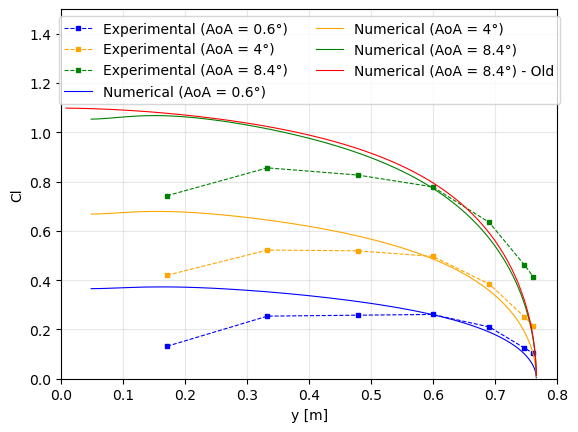

In [129]:
# --- Distribuição de Cl experimental em V30 ---
Re = 394724
y = np.array([0.222527415, 0.433896867, 0.623510444, 0.781856397, 0.900998695, 0.975, 0.994])*0.766

# AoA = 0.6 
CL_0 = [0.13177283653076205, 0.2539974844485991, 0.25786404572611754, 0.260809268730279, 0.2100831433923379, 
    0.12469508348003491, 0.10253974573554324]

# AoA = 4
CL_4 = [0.4199168065127933, 0.5222973283137413, 0.518990061274247, 0.49649509766952543, 0.38429549557151993,
    0.2506395921108621, 0.21463484836509553]

# AoA = 8.4
CL_8 = [0.7428363958362348, 0.8557645847333054, 0.8267461378318645, 0.7785770676909338, 0.6341582892477604, 
    0.4614852756929923, 0.41266905583173935]

# --- Numerical data ---
Yle = np.array([0.0071, 0.0214, 0.0356, 0.0498, 0.0640, 0.0782, 0.0923, 0.1064,
    0.1205, 0.1345, 0.1484, 0.1623, 0.1762, 0.1900, 0.2037, 0.2173,
    0.2308, 0.2443, 0.2576, 0.2709, 0.2840, 0.2971, 0.3100, 0.3228,
    0.3355, 0.3481, 0.3605, 0.3728, 0.3849, 0.3969, 0.4087, 0.4204,
    0.4319, 0.4433, 0.4545, 0.4655, 0.4763, 0.4869, 0.4974, 0.5077,
    0.5177, 0.5276, 0.5373, 0.5467, 0.5560, 0.5650, 0.5738, 0.5824,
    0.5908, 0.5989, 0.6068, 0.6145, 0.6219, 0.6291, 0.6361, 0.6428,
    0.6493, 0.6555, 0.6614, 0.6671, 0.6726, 0.6778, 0.6827, 0.6874,
    0.6918, 0.6959, 0.6998, 0.7034, 0.7067, 0.7097, 0.7125, 0.7150,
    0.7173, 0.7192, 0.7209, 0.7223, 0.7234, 0.7242, 0.7248, 0.7251]) + 0.0409

Cl_num_0 = [0.3655, 0.3660, 0.3671, 0.3684, 0.3697, 0.3709, 0.3719, 0.3724,
    0.3726, 0.3725, 0.3720, 0.3712, 0.3701, 0.3687, 0.3672, 0.3654,
    0.3634, 0.3613, 0.3590, 0.3566, 0.3541, 0.3514, 0.3486, 0.3457,
    0.3427, 0.3396, 0.3364, 0.3330, 0.3296, 0.3261, 0.3225, 0.3188,
    0.3150, 0.3111, 0.3071, 0.3030, 0.2988, 0.2945, 0.2901, 0.2855,
    0.2809, 0.2761, 0.2712, 0.2662, 0.2611, 0.2558, 0.2504, 0.2449,
    0.2393, 0.2335, 0.2276, 0.2215, 0.2153, 0.2090, 0.2025, 0.1959,
    0.1892, 0.1823, 0.1753, 0.1682, 0.1609, 0.1535, 0.1460, 0.1383,
    0.1306, 0.1227, 0.1147, 0.1067, 0.0985, 0.0903, 0.0819, 0.0735,
    0.0650, 0.0565, 0.0479, 0.0393, 0.0306, 0.0219, 0.0131, 0.0044]

Cl_num_4 = [0.6681, 0.6691, 0.6709, 0.6731, 0.6752, 0.6770, 0.6783, 0.6789,
    0.6789, 0.6783, 0.6772, 0.6756, 0.6736, 0.6711, 0.6684, 0.6653,
    0.6620, 0.6585, 0.6547, 0.6507, 0.6465, 0.6421, 0.6376, 0.6328,
    0.6279, 0.6228, 0.6176, 0.6121, 0.6065, 0.6007, 0.5947, 0.5885,
    0.5821, 0.5756, 0.5688, 0.5618, 0.5546, 0.5472, 0.5395, 0.5316,
    0.5235, 0.5151, 0.5065, 0.4976, 0.4885, 0.4791, 0.4694, 0.4595,
    0.4492, 0.4387, 0.4279, 0.4168, 0.4055, 0.3938, 0.3819, 0.3696,
    0.3571, 0.3443, 0.3312, 0.3179, 0.3043, 0.2904, 0.2763, 0.2619,
    0.2473, 0.2325, 0.2175, 0.2022, 0.1868, 0.1712, 0.1554, 0.1395,
    0.1234, 0.1072, 0.0909, 0.0745, 0.0580, 0.0415, 0.0249, 0.0083]

Cl_num_8 = [1.0534, 1.0548, 1.0573, 1.0603, 1.0632, 1.0656, 1.0672, 1.0679,
    1.0676, 1.0665, 1.0646, 1.0620, 1.0588, 1.0550, 1.0508, 1.0462,
    1.0412, 1.0358, 1.0301, 1.0241, 1.0179, 1.0113, 1.0045, 0.9974,
    0.9900, 0.9824, 0.9745, 0.9663, 0.9579, 0.9491, 0.9400, 0.9307,
    0.9210, 0.9110, 0.9006, 0.8899, 0.8789, 0.8674, 0.8557, 0.8435,
    0.8309, 0.8179, 0.8045, 0.7906, 0.7764, 0.7617, 0.7465, 0.7309,
    0.7148, 0.6982, 0.6812, 0.6637, 0.6457, 0.6273, 0.6083, 0.5889,
    0.5691, 0.5487, 0.5279, 0.5067, 0.4851, 0.4630, 0.4405, 0.4176,
    0.3943, 0.3707, 0.3467, 0.3224, 0.2977, 0.2728, 0.2477, 0.2223,
    0.1966, 0.1708, 0.1448, 0.1187, 0.0924, 0.0661, 0.0397, 0.0132]

Cl_num_old_8 = [1.0981, 1.0977, 1.0969, 1.0958, 1.0943, 1.0926, 1.0906, 1.0884,
    1.0859, 1.0832, 1.0802, 1.0769, 1.0735, 1.0698, 1.0658, 1.0617,
    1.0572, 1.0526, 1.0477, 1.0426, 1.0372, 1.0316, 1.0257, 1.0195,
    1.0131, 1.0064, 0.9994, 0.9921, 0.9845, 0.9766, 0.9684, 0.9598,
    0.9509, 0.9417, 0.9321, 0.9221, 0.9117, 0.9009, 0.8897, 0.8781,
    0.8661, 0.8535, 0.8406, 0.8271, 0.8132, 0.7987, 0.7838, 0.7683,
    0.7523, 0.7357, 0.7187, 0.7010, 0.6828, 0.6641, 0.6448, 0.6249,
    0.6045, 0.5835, 0.5620, 0.5399, 0.5173, 0.4942, 0.4706, 0.4465,
    0.4220, 0.3970, 0.3715, 0.3457, 0.3195, 0.2930, 0.2661, 0.2389,
    0.2114, 0.1837, 0.1558, 0.1277, 0.0995, 0.0712, 0.0427, 0.0142]

Yle_old = [0.0075, 0.0226, 0.0376, 0.0526, 0.0676, 0.0826, 0.0975, 0.1124,
    0.1273, 0.1421, 0.1568, 0.1715, 0.1861, 0.2007, 0.2152, 0.2295,
    0.2438, 0.2581, 0.2722, 0.2862, 0.3001, 0.3138, 0.3275, 0.3410,
    0.3544, 0.3677, 0.3808, 0.3938, 0.4066, 0.4193, 0.4318, 0.4441,
    0.4563, 0.4683, 0.4801, 0.4917, 0.5032, 0.5144, 0.5255, 0.5363,
    0.5469, 0.5574, 0.5676, 0.5776, 0.5873, 0.5969, 0.6062, 0.6153,
    0.6241, 0.6327, 0.6411, 0.6492, 0.6570, 0.6646, 0.6720, 0.6791,
    0.6859, 0.6925, 0.6988, 0.7048, 0.7105, 0.7160, 0.7212, 0.7262,
    0.7308, 0.7352, 0.7392, 0.7430, 0.7466, 0.7498, 0.7527, 0.7554,
    0.7577, 0.7598, 0.7615, 0.7630, 0.7642, 0.7651, 0.7657, 0.7660]

plt.plot(y, CL_0, label='Experimental (AoA = 0.6°)', color='blue', marker='s', linestyle='--', markersize=3, lw=0.8)
plt.plot(y, CL_4, label='Experimental (AoA = 4°)', color='orange', marker='s', linestyle='--', markersize=3, lw=0.8)
plt.plot(y, CL_8, label='Experimental (AoA = 8.4°)', color='green', marker='s', linestyle='--', markersize=3, lw=0.8)

plt.plot(Yle, Cl_num_0, label='Numerical (AoA = 0.6°)', linestyle='-', color='blue', lw=0.8)
plt.plot(Yle, Cl_num_4, label='Numerical (AoA = 4°)', linestyle='-', color='orange', lw=0.8)
plt.plot(Yle, Cl_num_8, label='Numerical (AoA = 8.4°)', linestyle='-', color='green', lw=0.8)

plt.plot(Yle_old, Cl_num_old_8, label='Numerical (AoA = 8.4°) - Old', linestyle='-', color='red', lw=0.8)

plt.xlabel('y [m]')
plt.ylabel('Cl')
plt.grid(True, alpha=0.3)
plt.xlim([0, 0.8])
plt.ylim([0, 1.5])

plt.legend(loc='upper center', fontsize=10, ncol=2)
plt.show()

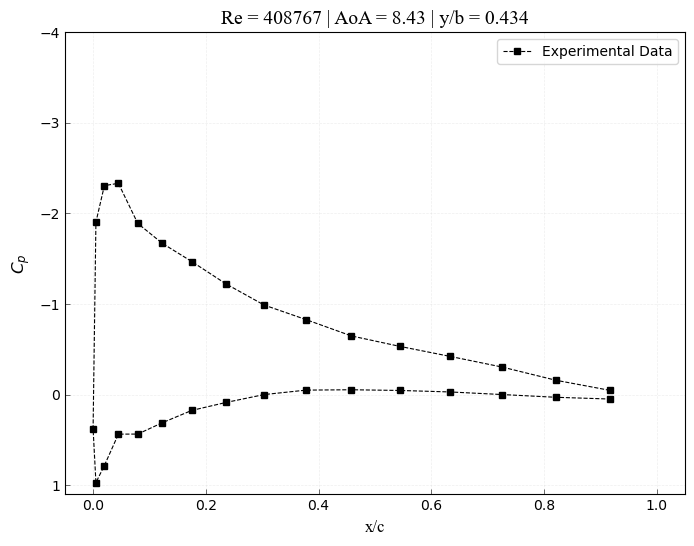

In [104]:
with open('utils/HighFidelity-Aviation-Sparse-PressureDistributionData.csv', 'r', encoding='utf-8') as f:
    header = f.readline().strip()

headers = header.split(';')

cp_headers_exp = np.array([float(col) for col in headers[5:]])

experimental_data = pd.read_csv('utils/HighFidelity-Aviation-Sparse-PressureDistributionData.csv', sep=';')
experimental_case = np.array(experimental_data[
    (experimental_data['Re'] == 408767) &
    (experimental_data['AoA'] == 8.429423727618087) & 
    (experimental_data['y'] == 0.433896867)])[0]

fig, ax = plt.subplots(figsize=(8, 6))
plot = ax.plot(cp_headers_exp, experimental_case[5:], marker='s', markersize=4, color='k', label='Experimental Data', 
    linestyle='--', linewidth=0.8)
ax.set_xlabel('x/c', fontsize=12, fontname='Times New Roman', labelpad=5)
ax.set_ylabel(r'$C_p$', fontsize=12, fontname='Times New Roman', labelpad=5)
Re, AoA, yb  = experimental_case[0], experimental_case[1], experimental_case[2]
ax.set_title(f'Re = {Re:.0f} | AoA = {AoA:.2f} | y/b = {yb:.3f}', fontsize=14, 
    fontname='Times New Roman')
ax.tick_params(axis='both', which='major', labelsize=10, width=0.4, direction='in')
ax.invert_yaxis()
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.2)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(1.1, -4)
ax.legend(loc='upper right', fontsize=10)
plt.savefig('CHECKVISUAL-2.png')
plt.show()

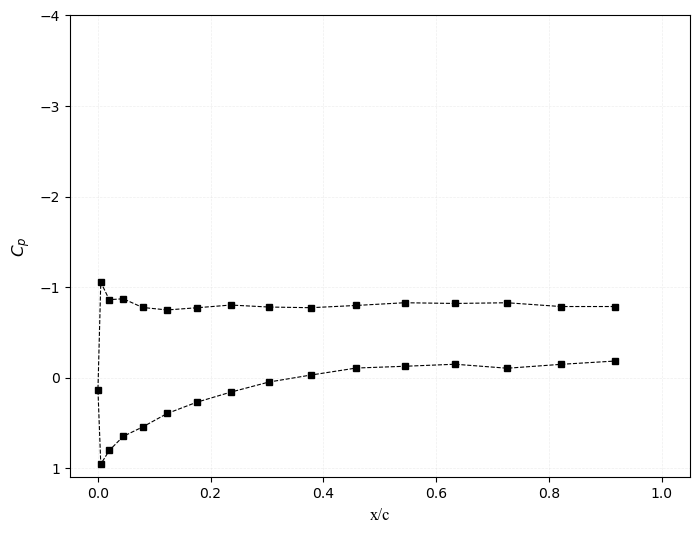

In [135]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

with open('pipeline-output/CompleteRun_V14_BravoConfig.csv', 'r', encoding='utf-8') as f:
    header = f.readline().strip()
headers = header.split(',')
cp_headers = np.array([float(col) for col in headers[5:]])

experimental_data = pd.read_csv('pipeline-output/CompleteRun_V14_BravoConfig.csv', sep=',')


experimental_case = experimental_data.iloc[36, 5:]

fig, ax = plt.subplots(figsize=(8, 6))
plot = plt.plot(cp_headers, experimental_case, marker='s', markersize=4, color='k', label='Experimental Data',
    linestyle='--', linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel('x/c', fontsize=12, fontname='Times New Roman', labelpad=5)
ax.set_ylabel(r'$C_p$', fontsize=12, fontname='Times New Roman', labelpad=5)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(1.1, -4)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.2)
plt.show()